## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che contiene migliaia di post su **Reddit (Random Acts of Pizza)** di utenti che chiedono una piazza in regalo e altri utenti che la offrono (o no). 

L'obiettivo dell'analisi è quello di effettuare una **Text Classification** per identificare chi ha ricevuto una pizza gratis e **Information Extraction**.

In questo primo notebook verrà implementato un **data preprocessing** al fine di preparare i dati da dare in pasto a modelli di ML-DL per la predizione e per l'estrazione di informazioni.

Per questa analisi verranno utilizzate librerie Python come **pandas, matplotlib, nltk, demoji e spacy**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione predittiva**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.13.5** di Python.

In [19]:
# Installazione delle dipendenze
%pip install -r requirements.txt
!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 5.4 MB/s eta 0:00:03
     ------------------- -------------------- 6.3/12.8 MB 22.2 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 29.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [20]:
import pandas as pd
import numpy as np
import re
import demoji
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

try:
    demoji.download_codes()
except:
    pass

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\matte\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\matte\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\matte\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### **Analisi del Dataset**

Il dataset comprende 4040 richieste di utenti collezionate nella community di Reddit **Random Acts of Pizza** dall'8 Dicembre 2010 al 29 Settembre 2013. Tutte le richieste chiedono una pizza gratis.

Per l'obiettivo di **Text Classification** e **Information Extraction** non serviranno tutte le colonne, quindi si effettuerà una selezione delle colonne cruciali per concentrarsi su una prima analisi del dataset.

- `request_title`: spesso il gancio emotivo è tutto qui (es. _"Ho perso il lavoro, ho fame"_ vs _"Serata cinema!"_)

- `request_text_edit_aware`: è preferibile utilizzare questa, invece di `request_text`. Questa versione del testo è "consapevole" degli edit, quindi spesso rimuove i ringraziamenti aggiunti dopo aver ricevuto la pizza, che porterebbe a data leakage.

- `requester_received_pizza`: questo è il **target** per la classificazione (True/False).

- Altri metadati: diverse metriche sull'attività dell'utente potrebbero essere utili per **valutare la reputazione** del richiedente.

In [21]:
train_df = pd.read_json('data/train/train.json')

print(train_df.columns)
print(train_df.shape)

Index(['giver_username_if_known',
       'number_of_downvotes_of_request_at_retrieval',
       'number_of_upvotes_of_request_at_retrieval', 'post_was_edited',
       'request_id', 'request_number_of_comments_at_retrieval', 'request_text',
       'request_text_edit_aware', 'request_title',
       'requester_account_age_in_days_at_request',
       'requester_account_age_in_days_at_retrieval',
       'requester_days_since_first_post_on_raop_at_request',
       'requester_days_since_first_post_on_raop_at_retrieval',
       'requester_number_of_comments_at_request',
       'requester_number_of_comments_at_retrieval',
       'requester_number_of_comments_in_raop_at_request',
       'requester_number_of_comments_in_raop_at_retrieval',
       'requester_number_of_posts_at_request',
       'requester_number_of_posts_at_retrieval',
       'requester_number_of_posts_on_raop_at_request',
       'requester_number_of_posts_on_raop_at_retrieval',
       'requester_number_of_subreddits_at_request', 'r

#### **Data Verification**

Prima di procedere con l'analisi, si calcolerà la **distribuzione** dei target, quindi la percentuale di richieste andate a buon fine. Inoltre, ai fini dell'analisi si sfrutteranno le colonne utili menzionate in precedenza, più la lista dei subreddit (`requester_subreddits_at_request`) che potrebbe essere utilizzata per l'**Information Extraction**.

In [22]:
# Controllo del bilanciamento delle classi
print("Distribuzione dei Target")
print(train_df['requester_received_pizza'].value_counts(normalize=True))

# Creazione di un DataFrame ridotto per l'analisi NLP
# Unione di Titolo e Testo per dare più contesto al modello
df_nlp = pd.DataFrame()
df_nlp['text'] = train_df['request_title'] + " " + train_df['request_text_edit_aware']

# Aggiunta dei subreddit frequentati come "tag"
df_nlp['tags'] = train_df['requester_subreddits_at_request'].apply(lambda x: " ".join(x) if isinstance(x, list) else "")
df_nlp['target'] = train_df['requester_received_pizza'].astype(int)

example_row = df_nlp[df_nlp['target'] == 1].iloc[0]

print("\n--- Esempio di richiesta di successo ---")
print(f"TESTO:\n{example_row['text'][:300]}...\n")
print(f"TAGS (Interessi Utente):\n{example_row['tags']}")

Distribuzione dei Target
requester_received_pizza
False    0.75396
True     0.24604
Name: proportion, dtype: float64

--- Esempio di richiesta di successo ---
TESTO:
[REQUEST] I'll give a two week xbox live code for a slice of pie! Feeling under the weather so I called out off work today! I hate requesting because I feel like I'm begging so I thought I'd give back! 

(I'd offer pizza if today were payday :C)...

TAGS (Interessi Utente):
AdviceAnimals AskReddit Autos IAmA RandomKindness Random_Acts_Of_Pizza TheFacebookDelusion atheism aww cars coupons fffffffuuuuuuuuuuuu funny gaming highdesert loseit pics reddit.com shittybattlestations todayilearned videos


Come poteva essere previsto, il risultato mostra uno **sbilanciamento delle classi**: solo il 24.6% delle richieste ottiene una pizza, mentre il 75.4% fallisce. Questo è cruciale per la scelta delle metriche di valutazione.

#### **Feature Engineering**

Per l'analisi NLP, è stato unito `request_title` e `request_text_edit_aware` in un'unica colonna `text`. Inoltre, è stata trasformata la lista dei subreddit (`requester_subreddits_at_request`) in una stringa unica `tags`. Questo permetterà di trattare gli interessi dell'utente come testo semplice.

### **Preprocessing Avanzato**

In questa fase è stata implementata una **pipeline di pulizia e normalizzazione** del testo specificamente adattata al dominio del dataset, affiancata all'**estrazione** di metadati numerici. L'obiettivo è trasformare il testo grezzo in un formato strutturato e semanticamente ricco per i modelli di predizione. Le operazioni svolte si articolano in quattro passaggi principali:

**1. Definizione di Dizionari per la Normalizzazione**

Sono state create risorse lessicali per standardizzare il linguaggio informale tipico di Reddit:
   - **Espansione delle contrazioni**: mappatura delle forme contratte standard (_es: don't --> do not_) per uniformare la sintassi.
   - **Gestione dello Slang**: creazione di un dizionario specifico per il dominio "Pizza", traducendo termini gergali (_es: za, pie --> pizza_), abbreviazioni di cortesia (_es: thx --> thanks_) e indicatori di stato economico o sociale (_es: broke --> poor_), riducendo così la varianza del vocabolario.

**2. Configurazione delle Stopwords**

Si è proceduto a una personalizzazione della lista standard delle _stopwords_ inglesi. Contrariamente alle pratiche generiche, sono stati **preservati** termini ritenuti discriminanti per il successo di una richiesta, suddivisi in categorie:
   - **Pronomi**: fondamentali per distinguere narrazioni personali da quelle collettive.
   - **Verbi Modali**: essenziali per identificare il tono della richiesta, possibilità e promesse future.
   - **Indicatori temporali e di cortesia**: termini che indicano urgenza (_now,today_) o gratitudine (_please, thanks_).
   - **Negazioni**: necessarie per mantenere il senso logico delle frasi.

**3. Pipeline di Preprocessing**

In questa fase, è stata definita una funzione di trasformazione che applica sequenzialmente le seguenti operazioni su ogni testo:
   - **Lowercasing**: conversione dei caratteri maiuscoli in minuscoli.
   - **Espansione**: applicazione dei dizionari di slang e contrazioni.
   - **Pulizia Rumore**: rimozione di URL, handle utente (@) e caratteri non alfabetici.
   - **Gestione Emoji**: conversione delle emoji nella loro descrizione testuale per non perdere informazioni emotive.
   - **Mascheramento Numeri**: sostituzione delle cifre con un token generico `_NUM_`.
   - **Tokenizzazione e Filtraggio**: suddivisione in token e rimozione delle stopwords non rilevanti.
   - **Doppia Lemmatizzazione**: riduzione delle parole alla loro radice, applicata ai primi sostantivi e successivamente ai verbi, per massimizzare la normalizzazione.

**4. Estrazione Feature e Salvataggio**

Infine, il dataset è stato arricchito con nuove colonne:
    - **Metadati Utente**: inserimento di feature numeriche quali timestamp, età dell'account, numero di commenti, karma e numero di subreddit frequentati.
    - **Metriche di lunghezza**: calcolo della lunghezza (caratteri e parole) sia sul testo originale che su quello processato.

Il dataset risultante, pulito e arricchito, è stato salvato in formato **.pkl** per le fasi successive di modellazione.

In [23]:
# --- 1. Dizionari di Espansione ---

# Contrazioni standard
contractions_dict = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "can't": "cannot", "i'm": "i am", "you're": "you are",
    "it's": "it is", "they're": "they are", "we're": "we are", "isn't": "is not",
    "aren't": "are not", "haven't": "have not", "hasn't": "has not",
    "wasn't": "was not", "weren't": "were not", "shouldn't": "should not",
    "wouldn't": "would not", "couldn't": "could not", "mustn't": "must not",
    "im": "i am", "dont": "do not", "cant": "cannot", "wont": "will not"
}

# Slang specifico per RAOP (Random Acts of Pizza)
pizza_slang_dict = {
    "za": "pizza", "pie": "pizza", "slice": "pizza",
    "broke": "poor", "paycheck": "money", "cash": "money", "bucks": "money", "bill": "bills",
    "starving": "hungry", "famished": "hungry",
    "thx": "thanks", "plz": "please", "pls": "please",
    "uni": "university", "bf": "boyfriend", "gf": "girlfriend",
    "hubby": "husband", "kiddo": "child", "tummy": "stomach",
    "pay it forward": "reciprocity"
}

combined_dict = {**contractions_dict, **pizza_slang_dict}

# --- 2. Configurazione Stopwords ---

# Parole importanti da non cancellare
important_words = {
    # Pronomi (Chi chiede? Io o Noi?)
    "i", "me", "my", "we", "us", "our", "you",
    # Verbi Modali (Fondamentali per promesse e cortesia)
    "will", "can", "could", "would", "should", "might", "must",
    # Negazioni
    "not", "no", "nor", "never", "n't",
    # Tempo (Urgenza)
    "now", "today", "tonight", "tomorrow", "yesterday", "week", "month", "friday",
    # Cortesia e Causa
    "please", "thanks", "thank", "because", "so", "since"
}

stop_words = set(stopwords.words('english')) - important_words

# --- 3. Funzioni Ausiliarie ---

def expand_slang(text):
    pattern = re.compile(r'\b(' + '|'.join(combined_dict.keys()) + r')\b')
    return pattern.sub(lambda x: combined_dict[x.group()], text)

def replace_emojis(text):
    return demoji.replace_with_desc(text, sep=" ")

def preprocess(text):
    """Pipeline completa per RAOP"""
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Espansione Contrazioni e Slang
    text = expand_slang(text)
    
    # 3. Rimozione URL e User Handle
    text = re.sub(r"http\S+|ww\S+|https\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    
    # 4. Gestione Emoji
    text = replace_emojis(text)
    
    # 5. Pulizia caratteri non alfabetici
    text = re.sub(r'\b\d+\b', ' _NUM_ ', text)
    text = re.sub(r"[^a-z\s_]", " ", text)
    
    # 6. Tokenizzazione
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text)
    
    # 7. Rimozione Stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # 8. Lemmatizzazione
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatizzazione base (nomi)
    tokens = [lemmatizer.lemmatize(word, pos='v') for word in tokens] # Lemmatizzazione verbi (es: giving -> give)
    
    return " ".join(tokens)

# --- 4. Applicazione Feature Extraction & Preprocessing ---

# Feature numeriche
df_nlp['timestamp'] = train_df['unix_timestamp_of_request']
df_nlp['account_age_days'] = train_df['requester_account_age_in_days_at_request']
df_nlp['num_comments'] = train_df['requester_number_of_comments_at_request']
df_nlp['karma'] = train_df['requester_upvotes_minus_downvotes_at_request']
df_nlp['num_subreddits'] = train_df['requester_number_of_subreddits_at_request']

# Feature lunghezza testo originale
df_nlp['text_length'] = df_nlp['text'].apply(len)
df_nlp['word_count'] = df_nlp['text'].apply(lambda x: len(x.split()))

# Preprocessing
print("\nApplicazione preprocessing...")
df_nlp['processed_text'] = df_nlp['text'].apply(preprocess)

# 3. Ricalcolo delle lunghezze sul nuovo testo processato
df_nlp['processed_text_length'] = df_nlp['processed_text'].apply(len)
df_nlp['processed_text_word_count'] = df_nlp['processed_text'].apply(lambda x: len(x.split()))

print("Prime 5 righe del testo processato:")
print(df_nlp[['target', 'processed_text']].head())

# 4. Salvataggio del nuovo dataset
df_nlp.to_pickle("data/train/00_train.pkl")
print("Dataset base salvato in data/train/00_train.pkl")


Applicazione preprocessing...
Prime 5 righe del testo processato:
   target                                     processed_text
0       0  request colorado spring help u please hi i nee...
1       0  request california no money i could use dinner...
2       0  request hungry couple dundee scotland would lo...
3       0  request canada ontario get home school need pi...
4       0  request old friend come visit would love fee d...
Dataset base salvato in data/train/00_train.pkl


Per confermare e visualizzare l'impatto del preprocessing, si mostrerà un grafico a barre per mostrare la **differenza media di lunghezza** tra testo originale e testo processato, in modo tale da visualizzare quanto **rumore** è stato rimosso.

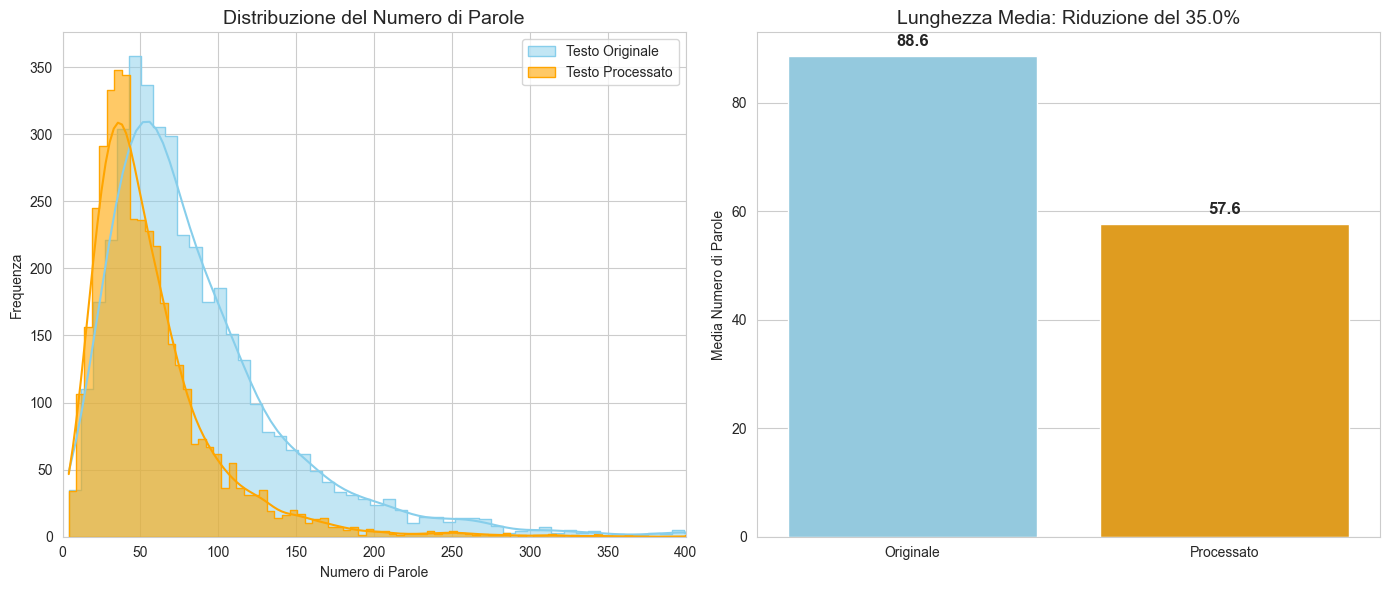

Statistiche:
- Media parole originali: 88.56
- Media parole processate: 57.59
- Riduzione media: 34.97%


In [24]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# 1. Istogramma per confrontare le distribuzioni
plt.subplot(1, 2, 1)
sns.histplot(df_nlp['word_count'], color='skyblue', label='Testo Originale', kde=True, element="step", alpha=0.5)
sns.histplot(df_nlp['processed_text_word_count'], color='orange', label='Testo Processato', kde=True, element="step", alpha=0.6)
plt.title('Distribuzione del Numero di Parole', fontsize=14)
plt.xlabel('Numero di Parole')
plt.ylabel('Frequenza')
plt.legend()
plt.xlim(0, 400) 

# 2. Barplot per la media
plt.subplot(1, 2, 2)
mean_original = df_nlp['word_count'].mean()
mean_processed = df_nlp['processed_text_word_count'].mean()
reduction_pct = ((mean_original - mean_processed) / mean_original) * 100

sns.barplot(x=['Originale', 'Processato'], y=[mean_original, mean_processed], palette=['skyblue', 'orange'])
plt.title(f'Lunghezza Media: Riduzione del {reduction_pct:.1f}%', fontsize=14)
plt.ylabel('Media Numero di Parole')

for i, v in enumerate([mean_original, mean_processed]):
    plt.text(i, v + 2, f"{v:.1f}", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Statistiche:")
print(f"- Media parole originali: {mean_original:.2f}")
print(f"- Media parole processate: {mean_processed:.2f}")
print(f"- Riduzione media: {reduction_pct:.2f}%")

L'analisi visiva e statistica dei testi prima e dopo il trattamento conferma l'efficacia della pipeline di pulizia.

- **Shift della distribuzione**: come evidenziato nell'istogramma a sinistra, la curva arancione (Testo Processato) mantiene la stessa forma della distribuzione originale (asimmetria positiva) ma risulta traslata verso sinistra. Questo indica una riduzione sistematica e coerente della lunghezza dei testi su tutto il dataset, senza introdurre distorsioni anomale.

- **Efficienza della Compressione**: il grafico a barre a destra quantifica l'impatto della pulizia. La lunghezza media delle richieste è scesa da 88.6 a 57.6 parole.

La riduzione del volume del testo del 35% suggerisce che è stato eliminato con successo il "rumore" grammaticale (articoli, preposizioni comuni, caratteri spuri) preservando al contempo il nucleo informativo necessario per i task.